CBDATSI Project - Phase 1

Members:
- Borromeo, Ed Bennett
- Dompor, Rovick
- Fuentes, Matthew

# Section 1: Dataset Description

For this notebook, the group will be working on a dataset called `RTA_EDSA_2007-2016`. 

The dataset is a collection of road traffic accidents that have occurred along Epifanio de los Santos Avenue (EDSA) in Metro Manila. It covers a 10-year period from 2007 to 2016.

### Dataset Collection Method
This dataset is sourced from Mendeley Data and is titled "Road Traffic Accident Data of Epifanio delos Santos Avenue, Metro Manila (2007-2016)." While originally provided as an `.xls` file, it was converted into a `.csv` format for the purposes of this notebook.

The raw data was collected from records maintained by the Metro Manila Development Authority (MMDA), utilizing the Data for Road Incident Visualization, Evaluation, and Reporting (DRIVER) System. To ensure comprehensive capture, the primary sources of this dataset include the MMDA Metrobase, the MMDA Road Safety Unit, and the Traffic Management Group of the Philippine National Police.

### Implications of Data Collection Method
The methodology used to collect this dataset introduces several inherent limitations that shape the conclusions of this study:

- Spatial and Temporal Scope: The findings derived from this dataset are strictly bounded to the EDSA corridor between 2007 and 2016. Consequently, the patterns discovered cannot be generalized to present-day traffic conditions or other major thoroughfares in Metro Manila.

- Reporting Bias: The dataset exclusively contains officially reported and recorded incidents through the MMDA and PNP. Minor collisions that were resolved privately between drivers without authoritative intervention are unrepresented. Therefore, the findings reflect patterns in official accident reporting, rather than an absolute count of all physical collisions that occurred.

- Unobserved Variables: The analysis is constrained by the features explicitly available in the dataset (e.g., location, date, time, severity, and collision type). External factors that heavily influence accident rates—such as sudden weather changes, real-time traffic volume, the presence of traffic enforcers, or driver behavior—are not captured and cannot be evaluated.


As a result of these limitations, the insights and findings generated in this notebook will be treated as historical patterns based solely on officially documented incidents, rather than a holistic or perfectly predictive representation of all accident occurrences along EDSA.

### Structure of the Data
The structure of the dataset is as follows:
- Each Row represents a report of a Road Traffic Accident that occured on EDSA.
- Each Column represents a datafield of a specfic aspect that report.
- There are a total of 22072 Rows and 26 Columns present in the dataset.

### Description of Variables

The following are the description of each datafield:
- `LOCATION_TEXT`: specifc location, in text, of where along EDSA the recorded accident occured
- `ROAD`: road where the recorded accident took place, this will always be EDSA
- `WEATHER`: type of weather when the recorded accident took place
- `LIGHT`: time of day when the recorded accident took place
- `DESC`: additional descriptions for the recorded accident
- `REPORTING_AGENCY`: agency that reported the recorded accident
- `MAIN_CAUSE`: cause of the recorded accident
- `INCIDENTDETAILS_ID`: id of the recorded accident
- `DATE_UTC`: date of the recorded accident in UTC
- `TIME_UTC`: time of the recorded accident in UTC
- `ADDRESS`: exact address of the recorded accident location
- `killed_driver`: number of drivers killed in the recorded accident
- `killed_passenger`: number of passengers killed in the recorded accident
- `killed_pedestrian`: number of pedestrians killed in the recorded accident
- `injured_driver`: number of drivers injured in the recorded accident
- `injured_passenger`: number of passengers injured in the recorded accident
- `injured_pedestrian`: number of pedestrians injured in the recorded accident
- `killed_uncategorized`: number of uncategorized killed in the recorded accident
- `injured_uncategorized`: number of uncategoried injured in the recorded accident
- `killed_total`: total number killed in the recorded accident
- `injured_total`: total number injured in the recorded accident
- `DATETIME_PST`: date and time of the recorded accident in PST
- `SEVERITY`: severity of the recorded accident
- `Y`: horizontal map coordinate of the recorded accident 
- `X`: vertical map coordinate of the recorded accident 
- `COLLISION_TYPE`: type of collision involved in the recorded accident

# Section 2: Data Cleaning


### Loading the dataset

There will be two libraries used in this Notebook, Pandas and matplotlib.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from models.data_processing import (
    X_MAX,
    X_MIN,
    Y_MAX,
    Y_MIN,
    add_hour_bin,
    add_severity_num,
    clean_edsa_address,
    drop_missing_address,
    extract_casualty_class,
    extract_hour,
    filter_columns,
    find_invalid_range_rows,
    normalize_address_column,
    validate_collision_type_values,
    validate_severity_values,
    validate_x_bounds,
    validate_y_bounds,
)

# the theme of the charts
plt.style.use('seaborn-v0_8-darkgrid')

%matplotlib inline


We will now load the dataset and check its contents.

In [2]:
RTA_df = pd.read_csv('RTA_EDSA_2007-2016.csv')
RTA_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22072 entries, 0 to 22071
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LOCATION_TEXT          304 non-null    object 
 1   ROAD                   22072 non-null  object 
 2   WEATHER                304 non-null    object 
 3   LIGHT                  304 non-null    object 
 4   DESC                   22072 non-null  object 
 5   REPORTING_AGENCY       22072 non-null  object 
 6   MAIN_CAUSE             304 non-null    object 
 7   INCIDENTDETAILS_ID     22072 non-null  object 
 8   DATE_UTC               22072 non-null  object 
 9   TIME_UTC               22072 non-null  object 
 10  ADDRESS                21768 non-null  object 
 11  killed_driver          22072 non-null  int64  
 12  killed_passenger       22072 non-null  int64  
 13  killed_pedestrian      22072 non-null  int64  
 14  injured_driver         22072 non-null  int64  
 15  in

### Removing Unnecessary Variables (Columns)

The important variables (datafields) needed for our Exploratory Data Analysis are:

 `ADDRESS`, `DATETIME_PST`, `SEVERITY`, `X`, `Y`, &, `COLLISION_TYPE`

The other variables will be dropped to lower the size and complexity of the dataset.

We will specify the variables to keep, drop the rest, and then check if the process was successful.

In [ ]:
RTA_df = filter_columns(RTA_df)

RTA_df.info()


The process has been successful; we have retained only the necessary variables and can now proceed to the next stage of data cleaning.

### Checking for NaN's

We want to remove any observations (rows) that has a value of NaN, let's check if there are any first.

In [4]:
RTA_df.isnull().any()

ADDRESS            True
DATETIME_PST      False
SEVERITY          False
Y                 False
X                 False
COLLISION_TYPE    False
dtype: bool

Since `ADDRESS` is the only variable with any NaN values. 


Let's first check the number of rows that have a NaN value.

In [5]:
rows_with_NaN = RTA_df[RTA_df['ADDRESS'].isnull()].index
print(f"Number of rows with NaN in ADDRESS: {len(rows_with_NaN)}")

Number of rows with NaN in ADDRESS: 304


With 304 rows containing NaN values, we have two options:
1. Fill in these missing values using the available X and Y coordinates that they have. 
2. Drop these rows from the dataset.

However, before we do anything let's go and check Address column first.

### Individual Variable Checking and Cleaning

### ADDRESS
Individually, let's check the unique values for each `ADDRESS` column to verify any spelling mistakes, multiple representations, or incorrect addresses.

In [6]:
RTA_df['ADDRESS'].unique()

array(['Congressional Ave. Edsa Quezon City',
       'Congressional Ave. near EDSA Exit Gate of SM Warehouse Bahay Toro Quezon City',
       'Congressional Ave. EDSA Quezon City', ...,
       'Kamuning    EDSA Quezon City',
       'Centris Station EDSA    Quezon City', nan],
      shape=(7814,), dtype=object)

There is a total of 7813 values, let's check the frequency of each.

In [7]:
RTA_df['ADDRESS'].value_counts()

ADDRESS
EDSA Taft Ave. Pasay                                         361
EDSA Aurora Blvd. Quezon City                                286
EDSA (SB) Ayala Ave. Makati                                  249
EDSA (SB) Estrella St. Makati                                222
EDSA P. Tuazon Blvd. Quezon City                             199
                                                            ... 
Mindanao Ave.  Edsa N/B Landmark Bldg. Quezon City             1
Mindanao Ave.  Edsa N/B Brgy. Bagong Pag Asa  Quezon City      1
Mindanao Ave. Near EDSA (N/B) Brgy.  Pag-Asa Quezon City       1
Mindanao Ave. Ext., before EDSA Quezon City                    1
Mindanao Ave. before EDSA Quezon City                          1
Name: count, Length: 7813, dtype: int64

Going back to the concerns regarding NaN values in the dataset, it appears that there is a significant number of unique entries for the `ADDRESS` variable.

Returning to our NaN decision:
With only 304 rows containing NaN values, this amount is relatively small compared to the total dataset. The effort required to fill these missing entries would be substantial, and there is a high risk of incorrectly imputing values, which could lead to silent errors within the dataset.

As a result, we have decided to drop these 304 rows. While this choice results in a minor loss of data, the percentage is negligible and will not significantly affect our overall findings.

In [ ]:
RTA_df = drop_missing_address(RTA_df)
RTA_df.info()


Let's clean the `ADDRESS` column using `normalize_address_column()`. This function handles all text normalization in one step: it strips leading and trailing whitespace, applies title casing to standardize capitalization, and then passes each address through `clean_edsa_address()` to expand abbreviations and fix directional tags.

In [ ]:
before = RTA_df['ADDRESS'].nunique()

RTA_df = normalize_address_column(RTA_df)

print(f"Unique addresses before: {before}")
print(f"Unique addresses after:  {RTA_df['ADDRESS'].nunique()}")


Internally, `normalize_address_column()` calls `clean_edsa_address()` on each row, which standardizes directional tags to `(NB)`/`(SB)`, barangay abbreviations (`Bgy`/`Brgy`/`Barangay` → `Brgy.`), U-Turn labels, road type abbreviations (`Ave`/`St`/`Blvd`), and city abbreviations (`Q.C.` → `Quezon City`). Let's check the values now.

In [ ]:
RTA_df['ADDRESS'].value_counts()


Let us now check the values for `ADDRESS` again.

In [11]:
RTA_df['ADDRESS'].value_counts()

ADDRESS
Edsa Taft Avenue Pasay                                                                         479
Edsa Aurora Boulevard Quezon City                                                              328
Edsa (SB) Ayala Avenue Makati                                                                  299
Edsa (SB) Estrella Street Makati                                                               271
Edsa Roxas Boulevard Pasay                                                                     270
                                                                                              ... 
Timog Avenue Edsa (SB) Quezon City                                                               1
Timog Avenue Near Edsa / Gma 7 Bldg. Quezon City                                                 1
Edsa (SB) In-Between Bernardino Street And Estrella St., Near Corner Estrella Street Makati      1
Kamuning Edsa Quezon City                                                                        1
Ed

Although the ADDRESS variable still contains a large number of unique values, this is geographically expected. These unique entries represent distinct locations along EDSA, and maintaining this level of detail is critical for accurate spatial analysis. Having successfully standardized the text formats and corrected directional inconsistencies, this variable is now clean, and we can proceed to preprocess the next feature.

### DATETIME_PST (HOUR)

This specific variable was chosen because we are from the Philippines, making it more ideal to follow Philippine Standard Time (PST) for accuracy and to avoid accounting for a 7-hour difference using UTC.

To further refine this variable, we only need the time rather than both the date and time. Therefore, we will first separate the date from the time.

First, we will convert the column values into Date and Time rather than together, using the pands method `.to_datetime`.

Afterwards, we ill introduce a new column into the dataset being `HOUR`.

In [ ]:
RTA_df = extract_hour(RTA_df)


Now to avoid complications with `DATETIME_PST` we will now drop it from the dataframe.

In [ ]:
# DATETIME_PST is already dropped inside extract_hour(), nothing further needed here.


Let's check to see how the dataset changes.

In [14]:
RTA_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21768 entries, 0 to 21767
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ADDRESS         21768 non-null  object 
 1   SEVERITY        21768 non-null  object 
 2   Y               21768 non-null  float64
 3   X               21768 non-null  float64
 4   COLLISION_TYPE  21768 non-null  object 
 5   HOUR            21768 non-null  int32  
dtypes: float64(2), int32(1), object(3)
memory usage: 935.5+ KB


Next, to verify all values, they must be within the range of 0 to 23.

In [ ]:
invalid_HOUR_rows = find_invalid_range_rows(RTA_df, 'HOUR', 0, 23)
print(f"Number of rows with invalid HOUR values: {len(invalid_HOUR_rows)}")


Looking at the print it seems all rows have valid HOUR values.

So, there are no problems with the values for HOUR; we can move to the next variable.

### SEVERITY

Let's check the unique values in `SEVERITY` and confirm they are within the known dataset categories using `validate_severity_values()`.

In [ ]:
print("Unique SEVERITY values:", RTA_df['SEVERITY'].unique())
print("Validated categories: ", validate_severity_values(RTA_df))


The severity values are confirmed to be within the three expected categories: `Property`, `Injury`, and `Fatal`. No spelling mistakes or unexpected labels are present.

We will now derive a binary `CASUALTY_CLASS` column using `extract_casualty_class()`, which maps `Property` → `Non_Casualty` and `Injury`/`Fatal` → `Casualty`. This will be useful for the classification model.

In [ ]:
RTA_df['CASUALTY_CLASS'] = RTA_df['SEVERITY'].apply(extract_casualty_class)

print(RTA_df['CASUALTY_CLASS'].value_counts())


### X and Y
To verify the validity of coordinate values within the bounds of EDSA road, we use the following references:

According to Nama-Admin (2022), EDSA's northern end is the Bonifacio Monument (Monumento) Circle in Caloocan, and its southern end is the SM Mall of Asia Globe Rotunda in Bay City, Pasay.

Using Google Maps as a reference for the coordinates, the geographic boundaries of EDSA are defined as follows:
- X: Minimum: 120.982, Maximum: 121.058  
- Y: Minimum: 14.532, Maximum: 14.657  

However, variations in GPS accuracy, road widths, and intersection dimensions can affect different types of maps. To account for these discrepancies, we will adjust the boundaries slightly. The operational boundaries for data validation in this notebook are:
- X: Minimum: 120.96, Maximum: 121.08  
- Y: Minimum: 14.51, Maximum: 14.68  

These boundaries ensure that the coordinates accurately represent the area of EDSA.

For X, we verify values fall between 120.96 and 121.08 using both `find_invalid_range_rows()` to inspect the flagged rows and `validate_x_bounds()` to get a direct invalid count.

In [ ]:
invalid_X_rows = find_invalid_range_rows(RTA_df, 'X', X_MIN, X_MAX)
print(f"Number of rows with invalid X values (find_invalid_range_rows): {len(invalid_X_rows)}")
print(f"Number of rows with invalid X values (validate_x_bounds):       {validate_x_bounds(RTA_df)}")


It seems that X variable has no invalid values, as such no need to further check.

So, there are no problems for X let's move on to Y.

For Y, we verify values fall between 14.51 and 14.68 using both `find_invalid_range_rows()` and `validate_y_bounds()`.

In [ ]:
invalid_Y_rows = find_invalid_range_rows(RTA_df, 'Y', Y_MIN, Y_MAX)
print(f"Number of rows with invalid Y values (find_invalid_range_rows): {len(invalid_Y_rows)}")
print(f"Number of rows with invalid Y values (validate_y_bounds):       {validate_y_bounds(RTA_df)}")


It seems that Y variable has no invalid values, as such no need to further check.

So, there are no problems for Y let's move on to the next variable.

### COLLISION_TYPE

Let's check the unique values first, then use `validate_collision_type_values()` to confirm there are no null or blank entries.

In [ ]:
print("Unique COLLISION_TYPE values:", RTA_df['COLLISION_TYPE'].unique())
print(f"Invalid/blank entries: {validate_collision_type_values(RTA_df)}")


No null or blank entries were found, and all values fall within the known dataset categories. There are no problems with `COLLISION_TYPE`; we can proceed to the EDA.

# Section 3: Exploratory Data Analysis (EDA)

We move on to EDA to gain a better understanding of our dataset.

Here are our 4 EDA questions:
1. How do recorded road accident frequencies and severity levels vary across descriptive locations along EDSA from 2007 to 2016?
2. Do fatal incidents occur at different times of day compared to injury and property-damage cases on EDSA?
3. Which reported collision types are most frequently associated with fatal and injury-related accidents?
4. Is there a relationship between the time of day and the type of collision that occurs on EDSA?

The questions follow a logical progression: beginning with *where* accidents occur (Q1), then *when* they occur by severity (Q2), then *how* they occur by severity (Q3), and finally combining *when* and *how* (Q4) to uncover deeper patterns in the data.

We will answer each question using both descriptive statistics and visualizations.

### EDA Question 1

We use the columns of `ADDRESS` and `SEVERITY` to answer this question.

First let's find measures of central tendency, measures of dispersion, and correlation. To do that, let's create a separate dataframe with only these 3 variables.

In [20]:
Q1_df = RTA_df.groupby(['ADDRESS', 'SEVERITY']).size().reset_index(name='COUNT')
Q1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6914 entries, 0 to 6913
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ADDRESS   6914 non-null   object
 1   SEVERITY  6914 non-null   object
 2   COUNT     6914 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 162.2+ KB


The pivot table from `Q1_df` is used to compute accident counts per location and severity type. Central tendency and dispersion are measured using the mean, median, mode, standard deviation, range, and IQR of total accidents per location. Pearson correlation is then applied to the severity-specific location counts to check whether locations with many property-damage accidents also tend to have many injury or fatal accidents.

In [21]:
severity_pivot = Q1_df.pivot_table(index='ADDRESS', columns='SEVERITY', values='COUNT', fill_value=0)
severity_pivot = severity_pivot.reindex(columns=['Property', 'Injury', 'Fatal'], fill_value=0)
severity_pivot['TOTAL'] = severity_pivot.sum(axis=1)

location_stats = severity_pivot['TOTAL'].describe()
location_iqr = location_stats['75%'] - location_stats['25%']

print("=== Central Tendency & Dispersion: Total Accidents per Location ===")
print(location_stats)
print(f"\nMode   : {severity_pivot['TOTAL'].mode()[0]:.0f}")
print(f"Range  : {severity_pivot['TOTAL'].max() - severity_pivot['TOTAL'].min():.0f}")
print(f"IQR    : {location_iqr:.2f}")

print("\n=== Top 10 Locations by Total Accident Count ===")
print(severity_pivot[['Property', 'Injury', 'Fatal', 'TOTAL']].sort_values('TOTAL', ascending=False).head(10))

print("\n=== Pearson Correlation between Severity Type Counts per Location ===")
print(severity_pivot[['Property', 'Injury', 'Fatal']].corr())

=== Central Tendency & Dispersion: Total Accidents per Location ===
count    6365.000000
mean        3.419953
std        14.632125
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       479.000000
Name: TOTAL, dtype: float64

Mode   : 1
Range  : 478
IQR    : 1.00

=== Top 10 Locations by Total Accident Count ===
SEVERITY                              Property  Injury  Fatal  TOTAL
ADDRESS                                                             
Edsa Taft Avenue Pasay                   442.0    36.0    1.0  479.0
Edsa Aurora Boulevard Quezon City        300.0    28.0    0.0  328.0
Edsa (SB) Ayala Avenue Makati            290.0     9.0    0.0  299.0
Edsa (SB) Estrella Street Makati         260.0    11.0    0.0  271.0
Edsa Roxas Boulevard Pasay               246.0    23.0    1.0  270.0
Edsa P. Tuazon Boulevard Quezon City     209.0    22.0    0.0  231.0
Edsa Quezon Avenue Quezon City           204.0    18.0    0.0  222.0
Edsa Shaw Boulevard Mandal

The top 15 locations are shown in three side-by-side panels — one per severity type — each on its own scale. This makes the Fatal pattern clearly visible without being dwarfed by the Property and Injury counts.

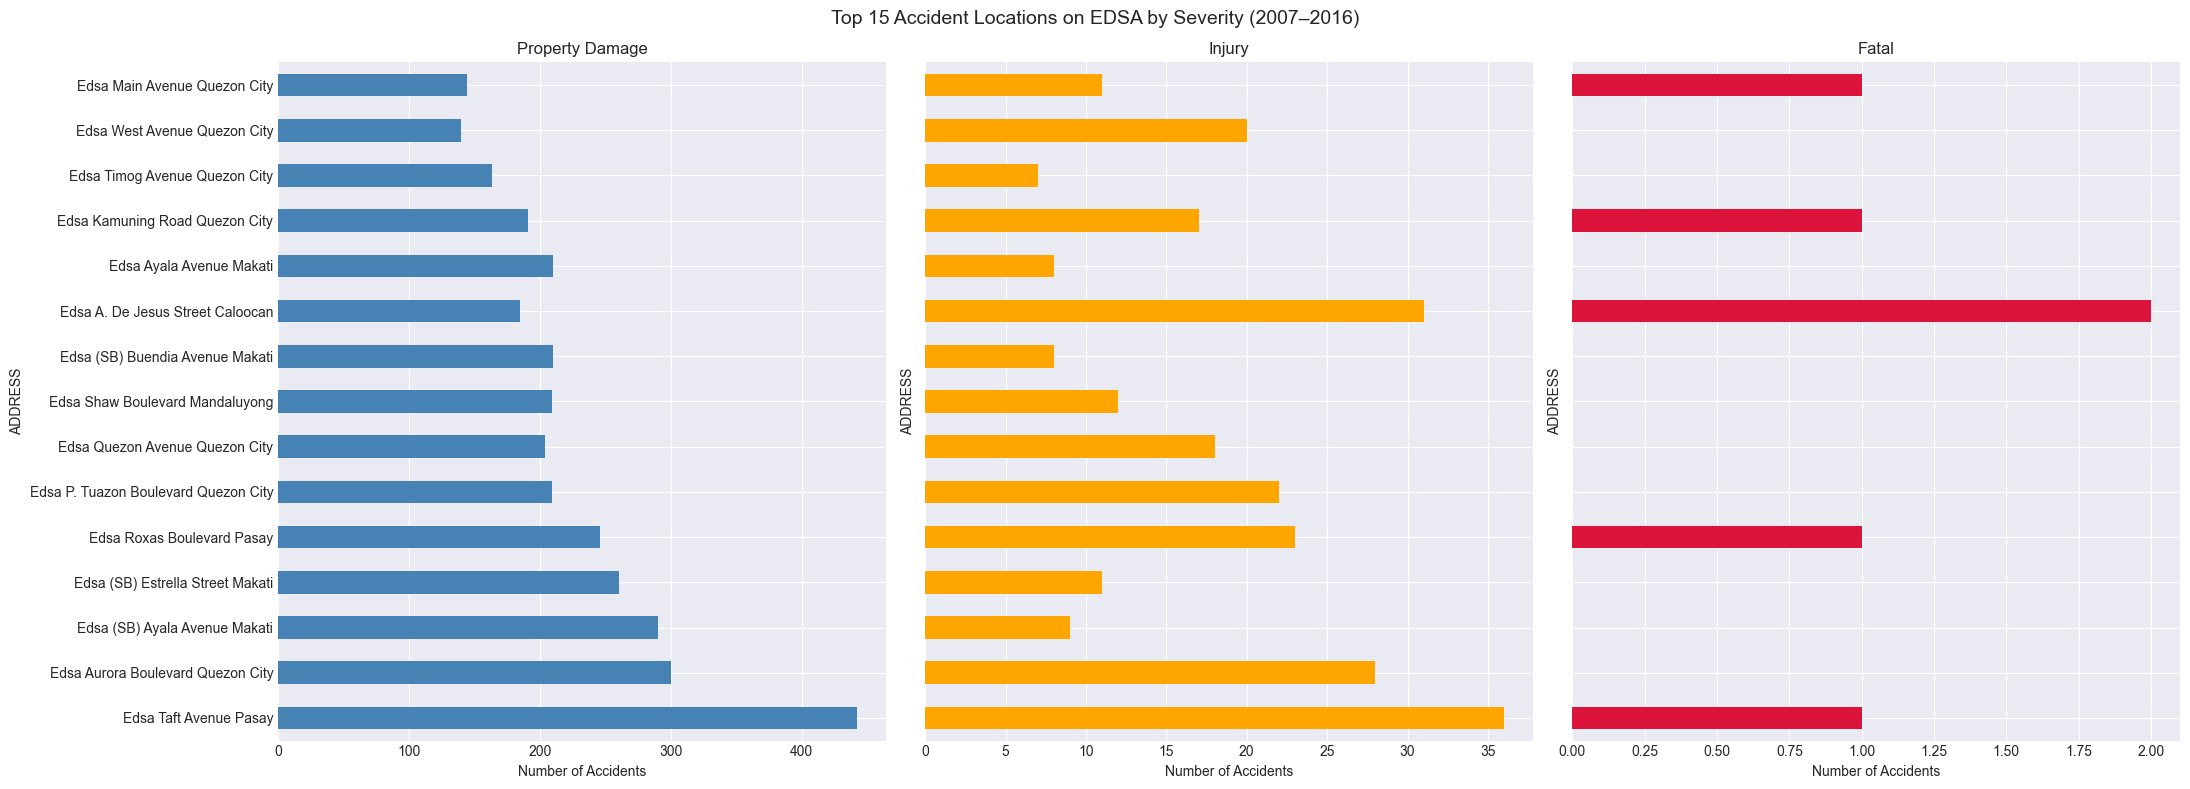

In [22]:
top15 = severity_pivot.nlargest(15, 'TOTAL')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 8))

top15[['Property']].plot(kind='barh', ax=ax1, color=['steelblue'], legend=False)
ax1.set_xlabel('Number of Accidents')
ax1.set_title('Property Damage')

top15[['Injury']].plot(kind='barh', ax=ax2, color=['orange'], legend=False)
ax2.set_xlabel('Number of Accidents')
ax2.set_title('Injury')
ax2.set_yticklabels([])

top15[['Fatal']].plot(kind='barh', ax=ax3, color=['crimson'], legend=False)
ax3.set_xlabel('Number of Accidents')
ax3.set_title('Fatal')
ax3.set_yticklabels([])

fig.suptitle('Top 15 Accident Locations on EDSA by Severity (2007–2016)', fontsize=14)
plt.tight_layout()
plt.show()

The three panels reveal that while the ranking of locations is broadly similar across all severity types, the Fatal panel shows a notably different distribution — some locations that rank highly for property damage do not rank as prominently for fatal accidents, suggesting that accident volume and accident danger do not always coincide.

### EDA Question 2

We use `DATETIME_PST` and `SEVERITY` to examine whether fatal incidents occur at different times of day compared to injury and property-damage cases. The timestamp is parsed and the hour of occurrence is extracted. Central tendency and dispersion are computed from the accident hour for each severity group. A severity-by-time-period crosstab is used to compare the percentage distribution of each severity level across the day. Pearson correlation is also computed between hour and a simple ordinal severity code as a basic correlation measure.

In [ ]:
RTA_df = add_severity_num(RTA_df)
RTA_df = add_hour_bin(RTA_df)

print("=== Central Tendency & Dispersion: Hour of Day by Severity ===")
print(RTA_df.groupby('SEVERITY')['HOUR'].describe())

print("\n=== Most Common Accident Hour by Severity ===")
print(RTA_df.groupby('SEVERITY')['HOUR'].agg(lambda x: x.mode().iloc[0]))

print("\n=== Time-of-Day Distribution within Each Severity (%) ===")
severity_hour_pct = pd.crosstab(RTA_df['SEVERITY'], RTA_df['HOUR_BIN'], normalize='index') * 100
print(severity_hour_pct.round(2))

print("\n=== Pearson Correlation: Hour and Ordinal Severity Code ===")
print(RTA_df[['HOUR', 'SEVERITY_NUM']].corr())


Hourly accident counts are shown in three stacked panels — one per severity type — each on its own scale. This makes the Fatal temporal pattern clearly visible without being obscured by the much larger Property and Injury volumes.

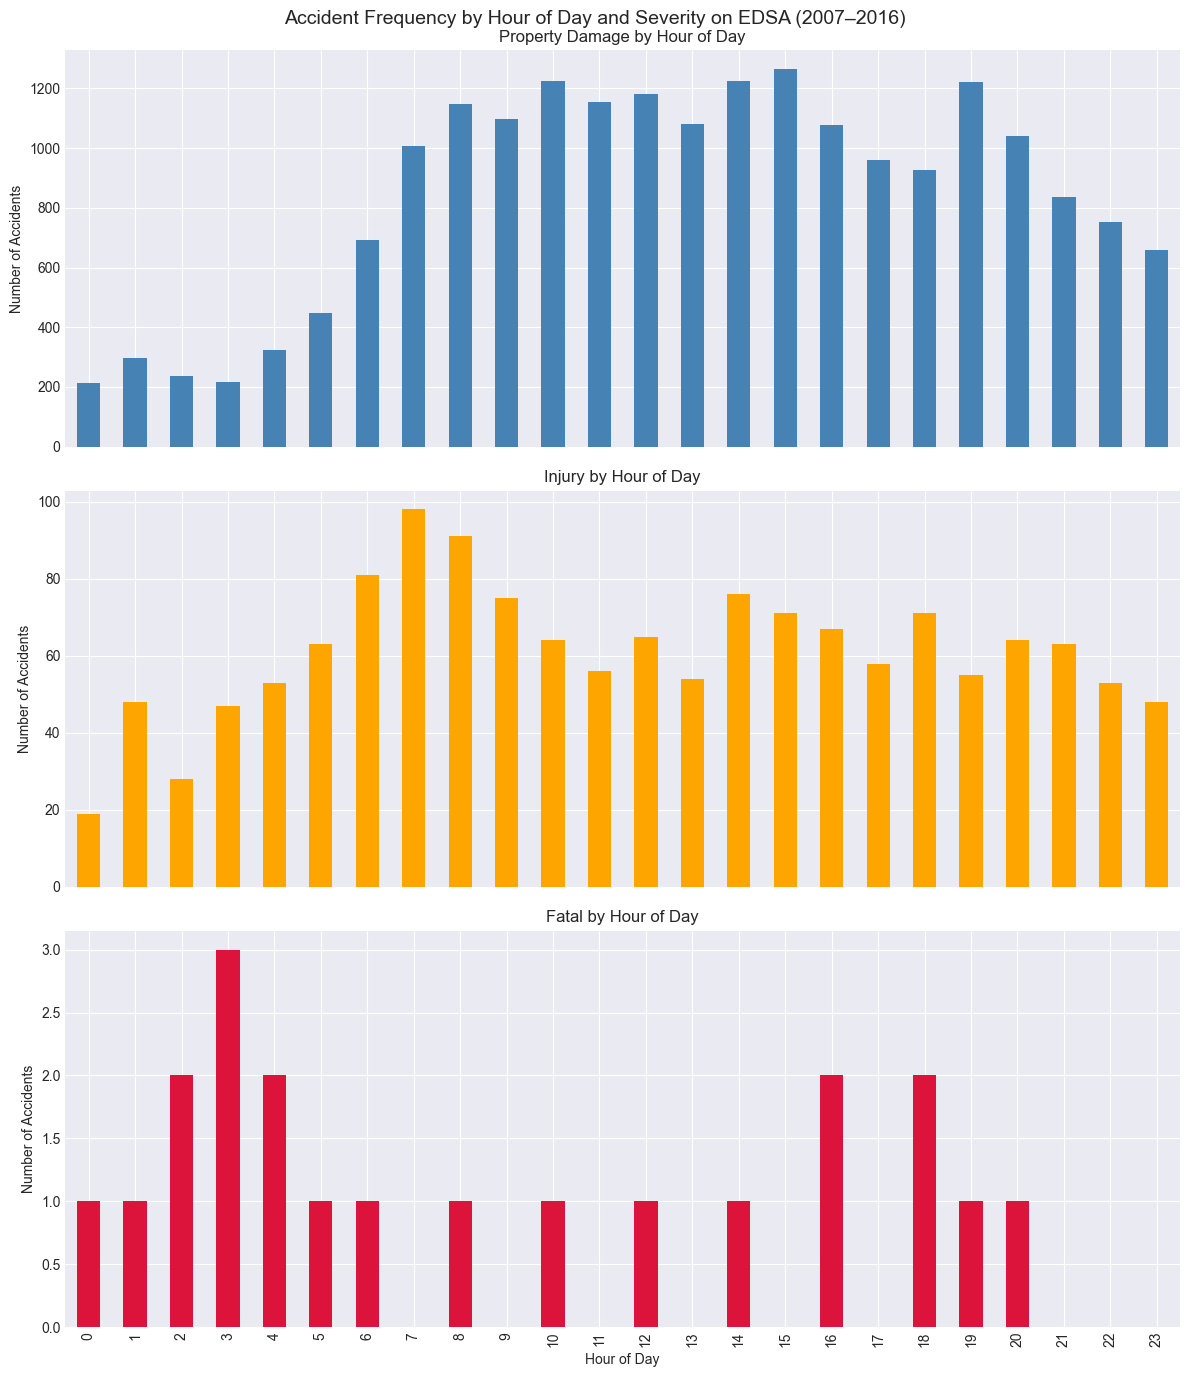

In [24]:
hourly_severity = RTA_df.groupby(['HOUR', 'SEVERITY']).size().unstack(fill_value=0)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

hourly_severity[['Property']].plot(kind='bar', ax=ax1, color=['steelblue'], legend=False)
ax1.set_ylabel('Number of Accidents')
ax1.set_title('Property Damage by Hour of Day')

hourly_severity[['Injury']].plot(kind='bar', ax=ax2, color=['orange'], legend=False)
ax2.set_ylabel('Number of Accidents')
ax2.set_title('Injury by Hour of Day')

hourly_severity[['Fatal']].plot(kind='bar', ax=ax3, color=['crimson'], legend=False)
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Number of Accidents')
ax3.set_title('Fatal by Hour of Day')

fig.suptitle('Accident Frequency by Hour of Day and Severity on EDSA (2007–2016)', fontsize=14)
plt.tight_layout()
plt.show()

All three panels peak during daytime hours, consistent with higher traffic volumes. The Fatal panel reveals a distinct pattern — fatal accidents are more evenly spread across all hours including late night and early morning, suggesting that while fewer accidents occur at those hours, they carry a higher risk of fatality, consistent with the low but present correlation between hour and severity.

### EDA Question 3

We use `COLLISION_TYPE` and `SEVERITY` to examine which collision types are most frequently associated with fatal and injury-related accidents. Central tendency and dispersion are computed from accident counts per collision type, while the mode identifies the most common collision type overall. A normalized crosstab shows the severity distribution within each collision type, and Pearson correlation is computed across collision-type count summaries to compare how property, injury, fatal, and total counts move together.

In [25]:
ct_counts = RTA_df.groupby('COLLISION_TYPE').size().reset_index(name='COUNT').sort_values('COUNT', ascending=False)

ct_count_stats = ct_counts['COUNT'].describe()
ct_count_iqr = ct_count_stats['75%'] - ct_count_stats['25%']

print("=== Central Tendency & Dispersion: Accident Count per Collision Type ===")
print(ct_count_stats)
print(f"\nMode collision type : {RTA_df['COLLISION_TYPE'].mode()[0]}")
print(f"Median count        : {ct_counts['COUNT'].median():.2f}")
print(f"Range               : {ct_counts['COUNT'].max() - ct_counts['COUNT'].min():.0f}")
print(f"IQR                 : {ct_count_iqr:.2f}")

print("\n=== Collision Type Frequencies ===")
print(ct_counts)

print("\n=== Association: Severity Distribution per Collision Type (%) ===")
ct_crosstab_pct = pd.crosstab(RTA_df['COLLISION_TYPE'], RTA_df['SEVERITY'], normalize='index') * 100
ct_crosstab_pct = ct_crosstab_pct.reindex(columns=['Property', 'Injury', 'Fatal'], fill_value=0)
ct_crosstab_pct['Casualty Rate'] = ct_crosstab_pct['Injury'] + ct_crosstab_pct['Fatal']
print(ct_crosstab_pct.round(2))

print("\n=== Collision Types Most Associated with Casualty Outcomes ===")
print(ct_crosstab_pct[['Injury', 'Fatal', 'Casualty Rate']].sort_values('Casualty Rate', ascending=False).round(2))

print("\n=== Pearson Correlation between Severity Counts by Collision Type ===")
ct_severity_counts = pd.crosstab(RTA_df['COLLISION_TYPE'], RTA_df['SEVERITY'])
ct_severity_counts = ct_severity_counts.reindex(columns=['Property', 'Injury', 'Fatal'], fill_value=0)
ct_severity_counts['Total'] = ct_severity_counts.sum(axis=1)
ct_severity_counts['Casualty Rate'] = (ct_severity_counts['Injury'] + ct_severity_counts['Fatal']) / ct_severity_counts['Total']
print(ct_severity_counts[['Property', 'Injury', 'Fatal', 'Total', 'Casualty Rate']].corr().round(3))

=== Central Tendency & Dispersion: Accident Count per Collision Type ===
count       8.000000
mean     2721.000000
std      3127.496169
min        45.000000
25%       307.250000
50%       945.000000
75%      5759.500000
max      7182.000000
Name: COUNT, dtype: float64

Mode collision type : No Collision Stated
Median count        : 945.00
Range               : 7137
IQR                 : 5452.25

=== Collision Type Frequencies ===
        COLLISION_TYPE  COUNT
4  No Collision Stated   7182
7           Side Swipe   6628
5             Rear-End   5470
0         Angle Impact   1344
2           Hit Object    546
3             Multiple    338
6        Self-Accident    215
1              Head-On     45

=== Association: Severity Distribution per Collision Type (%) ===
SEVERITY             Property  Injury  Fatal  Casualty Rate
COLLISION_TYPE                                             
Angle Impact            91.07    8.85   0.07           8.93
Head-On                 77.78   22.22   0.00     

Injury and Fatal percentages per collision type are plotted as a grouped horizontal bar chart, sorted by Fatal rate. Property-damage outcomes are excluded since Q3 focuses specifically on which collision types are most associated with casualties.

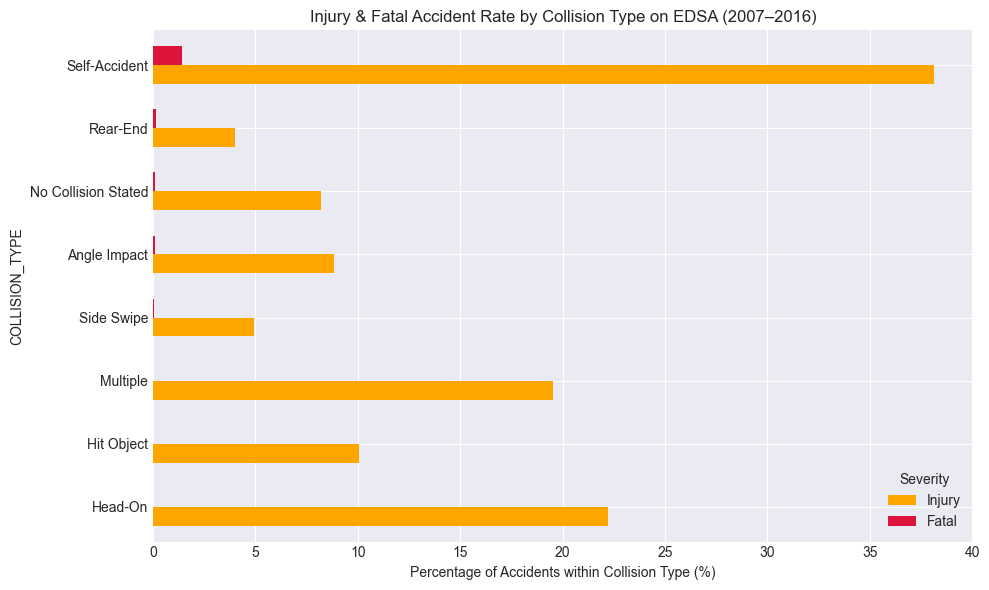

In [26]:
injury_fatal = ct_crosstab_pct[['Injury', 'Fatal']].sort_values('Fatal', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
injury_fatal.plot(kind='barh', ax=ax, color=['orange', 'crimson'], width=0.6)
ax.set_xlabel('Percentage of Accidents within Collision Type (%)')
ax.set_title('Injury & Fatal Accident Rate by Collision Type on EDSA (2007–2016)')
ax.legend(title='Severity')
plt.tight_layout()
plt.show()

Self-Accident collisions have the highest fatal rate and the highest overall casualty rate, while Head-On and Multiple collisions show high injury proportions despite having smaller total counts. Rear-End, Side Swipe, and No Collision Stated cases are more strongly associated with property-damage outcomes. This means collision type is useful for distinguishing casualty-prone accidents from mostly property-damage accidents.

### EDA Question 4

We use `HOUR` and `COLLISION_TYPE` to examine whether the time of day is associated with the type of collision on EDSA. Central tendency and dispersion of accident hours are computed per collision type. A normalized cross-tabulation across four time-of-day bins is used to compare when each collision type occurs. Pearson correlation is also computed on hourly collision-type counts to check whether collision types follow similar or different hourly patterns.

In [ ]:
print("=== Central Tendency & Dispersion: Hour of Day by Collision Type ===")
print(RTA_df.groupby('COLLISION_TYPE')['HOUR'].describe())

print("\n=== Most Common Accident Hour by Collision Type ===")
print(RTA_df.groupby('COLLISION_TYPE')['HOUR'].agg(lambda x: x.mode().iloc[0]))

print("\n=== Association: Collision Type Distribution by Time of Day (%) ===")
ct_hour_pct = pd.crosstab(RTA_df['COLLISION_TYPE'], RTA_df['HOUR_BIN'], normalize='index') * 100
print(ct_hour_pct.round(2))

print("\n=== Pearson Correlation between Collision-Type Hourly Patterns ===")
ct_hour_counts = pd.crosstab(RTA_df['HOUR'], RTA_df['COLLISION_TYPE'])
print(ct_hour_counts.corr().round(3))


A heatmap displays the percentage of each collision type's accidents at every hour of the day. This reveals whether certain collision types concentrate at specific times, showing the association between time of day and collision type across the EDSA dataset.

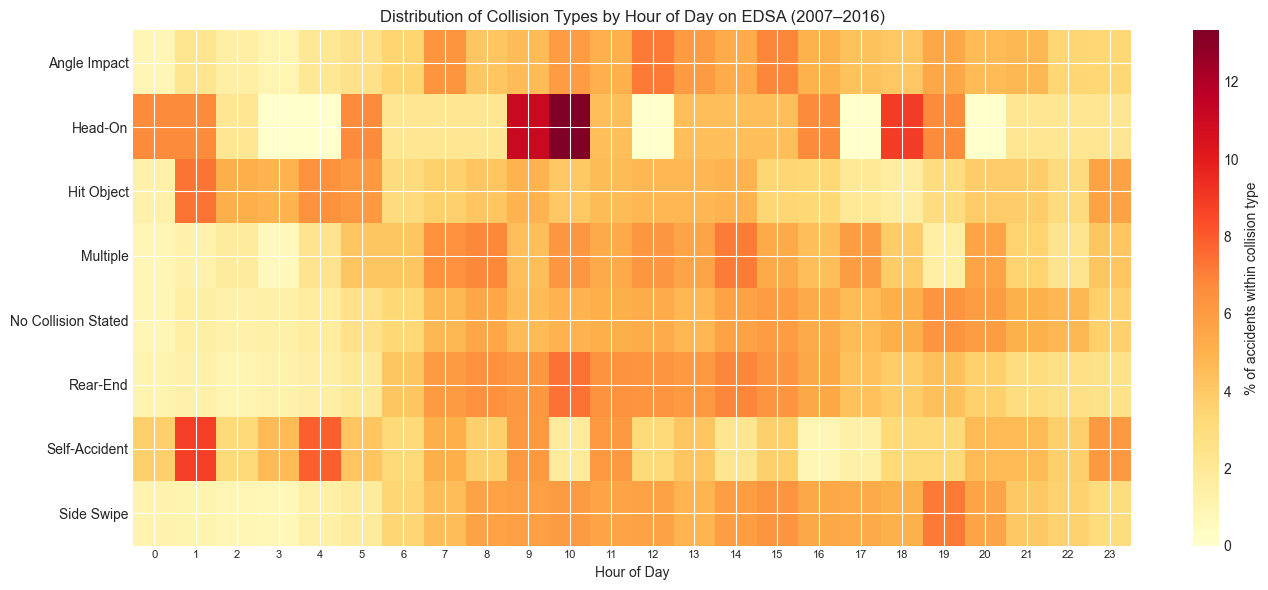

In [28]:
heatmap_data = pd.crosstab(RTA_df['COLLISION_TYPE'], RTA_df['HOUR'])
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_pct.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=8)
ax.set_yticks(range(len(heatmap_pct.index)))
ax.set_yticklabels(heatmap_pct.index)
plt.colorbar(im, ax=ax, label='% of accidents within collision type')
ax.set_xlabel('Hour of Day')
ax.set_title('Distribution of Collision Types by Hour of Day on EDSA (2007–2016)')
plt.tight_layout()
plt.show()

The heatmap reveals that collision types are not uniformly distributed across hours of the day. Certain types concentrate during peak traffic hours while others show higher proportions during nighttime or early morning periods, confirming that the time of day is associated with the type of collision that tends to occur on EDSA.

# Research Question

**What accident profiles along EDSA are associated with higher casualty risk based on collision type, time of day, location, and severity from 2007 to 2016?**

This research question was chosen because the exploratory data analysis showed that accident frequency and accident severity do not always follow the same pattern. Some locations have high total accident counts, but fatal accidents do not always appear in the same proportions as property-damage or injury accidents. The EDA also showed that fatal incidents tend to occur at different hours compared to injury and property-damage cases, and that some collision types, especially Self-Accident, Head-On, and Multiple collisions, appear to be more strongly associated with casualty outcomes than more common collision types such as Rear-End or Side Swipe.

Because of these findings, it is not enough to only identify where or when accidents are most frequent. A more meaningful next step is to identify accident profiles, or combinations of characteristics, that are linked to higher casualty risk. These profiles may include collision type, time of day, location, and severity. This research question is important because it can help distinguish ordinary high-volume accident patterns from lower-frequency but more dangerous accident patterns.


References:
- Nama-Admin. (2022, July 23). It’s More Fun With Juan: EDSA: Guide to Epifanio de los Santos Avenue (C-4 of Manila). It’s More Fun With Juan. https://www.morefunwithjuan.com/2022/07/edsa-epifanio-de-los-santos-avenue.html 